In [8]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("iris.csv.csv")

Saving iris.csv.csv to iris.csv (2).csv


First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical Summary:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000

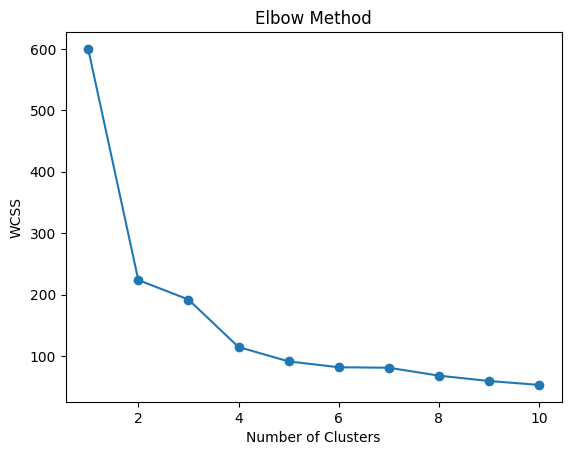

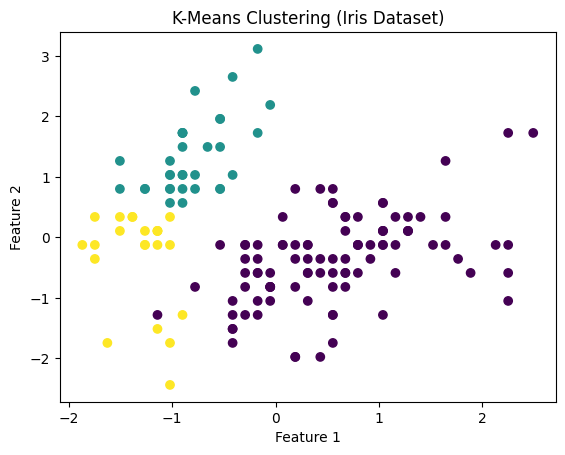


Cluster Means:
         sepal_length  sepal_width  petal_length  petal_width
Cluster                                                      
0            6.314583     2.895833      4.973958     1.703125
1            5.178125     3.631250      1.496875     0.278125
2            4.754545     2.904545      1.745455     0.336364


,sepal_length,sepal_width,petal_length,petal_width
Cluster,,,,
0,6.314583,2.895833,4.973958,1.703125
1,5.178125,3.631250,1.496875,0.278125
2,4.754545,2.904545,1.745455,0.336364


In [13]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("iris.csv (2).csv")  # change name if needed

# ==============================
# 3. Explore Data
# ==============================
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# ==============================
# 4. Data Preprocessing
# ==============================
# Remove categorical column
df = df.drop('species', axis=1)

# ==============================
# 5. Feature Scaling
# ==============================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# ==============================
# 6. Elbow Method
# ==============================
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# ==============================
# 7. Apply K-Means (K=3)
# ==============================
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels
df['Cluster'] = clusters

# ==============================
# 8. Visualize Clusters
# ==============================
plt.figure()
plt.scatter(scaled_data[:, 0], scaled_data[:, 1], c=clusters)
plt.title('K-Means Clustering (Iris Dataset)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# ==============================
# 9. Cluster Analysis
# ==============================
print("\nCluster Means:")
print(df.groupby('Cluster').mean())
df.groupby('Cluster').mean()